# **Predicting Student Academic Performance Using Machine Learning**

The project provides the machine learning pipeline of predicting students passing or failing based on the demographic characteristics and test scores.

We have defined this as a binary classification problem and make comparisons:

- Logistic Regression
- Support Vector Machine
- Artificial Neural Network
- Random Forest

The general objectives of this project include:

- To investigate the trend in student performance data.
- To design informative predictive feature.
- To compare a number of machine learning models.
- To test a model by cross-validation.
- To think over ethical and social implications.


## **Import libraries**
This cell imports all the necessary libraries required throughot the project.

- **pandas** and **numpy** used for data manipulation
- **matplotlib** for visualisation
- **scikit-learn** for preprocessing, modelling, hyperparameter tuning and evaluation

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    ConfusionMatrixDisplay
)

np.random.seed(42)
random.seed(42)
sns.set(style="whitegrid")


## **Load the Dataset**
The dataset used in this project is obtained from kaggel dataset. The dataset contains demographic attributes and exam scores of the students. The dataset represents a real-world educational context of academic and socio-economic factors.

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print(df.columns)


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


## **Feature Engineering**

To contruct a suitable prediction target, the average exam score was calculated from reading, writing and mathematics.

Binary target variable, **pass/fail** was created
- 1 indicates pass
- 0 indicates fail

This re-evaluates the issue as a supervised binary classification problem.

In [4]:
df["final_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["pass_fail"] = df["final_score"].apply(lambda x: 1 if x >= 50 else 0)

df = df.drop(columns=["math score", "reading score", "writing score", "final_score"])


## **Data Preprocessing and Train-Test split**

It was turned into numerical format through one-hot encoding with the help of the pd.get_dummies function.
The input features were then separated out and the target variable (pass- fail ) was obtained:

- **X**: the feature matrix  
- **y**: the binary class labels

An 80/20 split was used to develop a training and a test dataset.

The stratified sampling was used to maintain the proportion of pass and fail cases in both sets.




In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("pass_fail", axis=1)
y = df_encoded["pass_fail"]

X.shape, y.shape


((1000, 12), (1000,))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## **Evaluation Metrics**

Each model was evaluated using several classification meterics such as accuracy, precision, recall,
F1-score and ROC-AUC.

Recall was prioritised during model tuning to identify students who are at risk of failing.


In [7]:
def evaluate(model_name, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs),
        "Probs": probs
    }

results = []


## **Logistic Regression Model**

The model is used as a baseline classification method for predicting student outcomes. This model estimates the probability of students passing by learning a linear relationship between the input features and the target variable.


In [8]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_params = {
    "lr__C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring="recall"
)

lr_grid.fit(X_train, y_train)

results.append(
    evaluate(
        "Logistic Regression",
        lr_grid.best_estimator_,
        X_test,
        y_test
    )
)


## **Support Vector Machine**

SVM classifier is used to train and seperate passing and failing students. Scaling was applied and outputs were enabled so that ROC-AUC scores could be calculated.
Model allows non-linear decision boundaries to be learned.

In [9]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True))
])

svm_params = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=5,
    scoring="recall"
)

svm_grid.fit(X_train, y_train)

results.append(
    evaluate(
        "SVM",
        svm_grid.best_estimator_,
        X_test,
        y_test
    )
)


## **Random Forest Model**

The model combines multiple decision trees to improve predictive performance. Hyperparameters such as the number of trees and maximun depth were tuned using cross-validation.
To handle any imbalance between pass and fail cases class weighting was applied

In [10]:
rf_pipeline = Pipeline([
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

rf_params = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

results.append(
    evaluate(
        "Random Forest",
        rf_grid.best_estimator_,
        X_test,
        y_test
    )
)


## **Artificial Neural Network**

The model is used to train to capture complex relations in the data. Cross-validarion is combined with grid search to tune parameters such as network size and regularisation strength.
To limit the overfitting and reduce taining time early stopping was applied. The tuning focused on improving recall.

In [11]:

ann_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ann", MLPClassifier(
        max_iter=800,
        early_stopping=True,
        random_state=42
    ))
])

ann_params = {
    "ann__hidden_layer_sizes": [(50, 25), (100, 50), (100,)],
    "ann__alpha": [0.0001, 0.001, 0.01],
    "ann__learning_rate_init": [0.001, 0.01]
}

ann_grid = GridSearchCV(
    ann_pipeline,
    ann_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

ann_grid.fit(X_train, y_train)

results.append(
    evaluate(
        "ANN",
        ann_grid.best_estimator_,
        X_test,
        y_test
    )
)


## **Experimental Results**

This cell summarises the performance of all trained model on the test sets. The result table allows comparison between different evalustion metrics. The outcome are used to identify the most suitable model.

In [12]:
results_df = pd.DataFrame(results)

results_df["Score"] = (
    0.35 * results_df["Recall"] +
    0.25 * results_df["ROC_AUC"] +
    0.2 * results_df["F1"] +
    0.2 * results_df["Accuracy"]
)

results_df = results_df.sort_values(by="Score", ascending=False)
results_df


,Model,Accuracy,Recall,Precision,F1,ROC_AUC,Probs,Score
0,Logistic Regression,0.895,1.000000,0.895000,0.944591,0.793030,"[0.854574961030309, 0.8802051355827388, 0.8209...",0.916176
1,SVM,0.895,1.000000,0.895000,0.944591,0.762038,"[0.8581880425767906, 0.8195195280818269, 0.819...",0.908428
3,ANN,0.895,1.000000,0.895000,0.944591,0.701516,"[0.6428203688886949, 0.7593394246407187, 0.731...",0.893297
2,Random Forest,0.770,0.804469,0.929032,0.862275,0.671588,"[0.5247879225114748, 0.41076429736889253, 0.45...",0.775916


In [13]:
best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    best_model = lr_grid.best_estimator_
elif best_model_name == "SVM":
    best_model = svm_grid.best_estimator_
elif best_model_name == "Random Forest":
    best_model = rf_grid.best_estimator_
else:
    best_model = ann_pipeline

print("Best Model Selected:", best_model_name)


Best Model Selected: Logistic Regression


## **Correlation Analysis**

The training data is converted to a Dataframe if necessary. Correlation matrix is computed to explore the relation between numerical features.

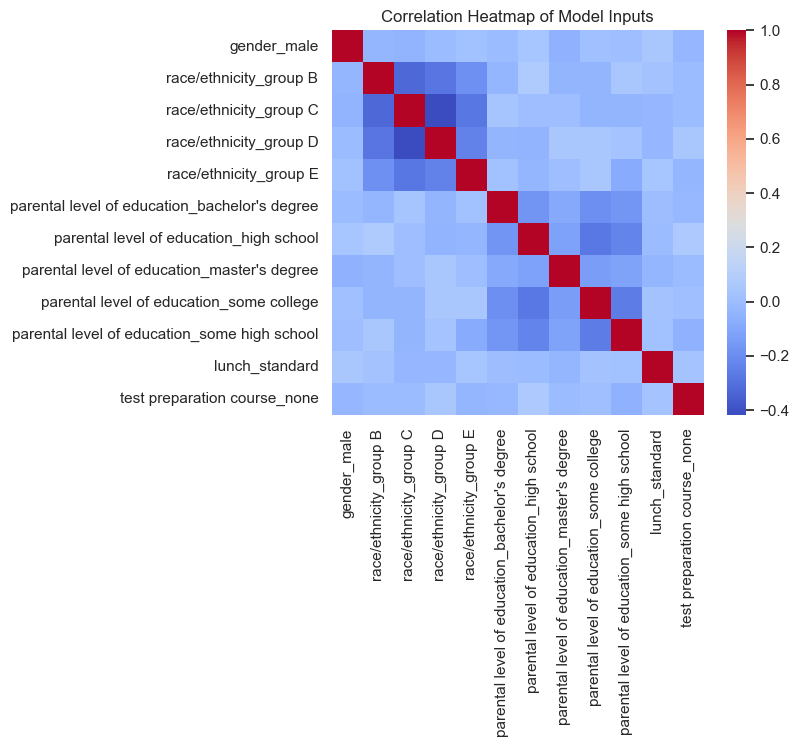

In [14]:
# convert X_train to DataFrame if needed
if not isinstance(X_train, pd.DataFrame):
    X_df = pd.DataFrame(X_train)
else:
    X_df = X_train.copy()

# compute correlation
corr = X_df.corr()

if corr.empty or corr.shape[0] < 2:
    print("Cannot plot correlation heatmap at this stage — features are already transformed.")
else:
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, cmap="coolwarm")
    plt.title("Correlation Heatmap of Model Inputs")
    plt.show()


## **Score Distribution Plot**

Kernel Density Estimation (KDE) plots are drawn for Math, Reading, Writing. Distributions are compared between passing and failing students.

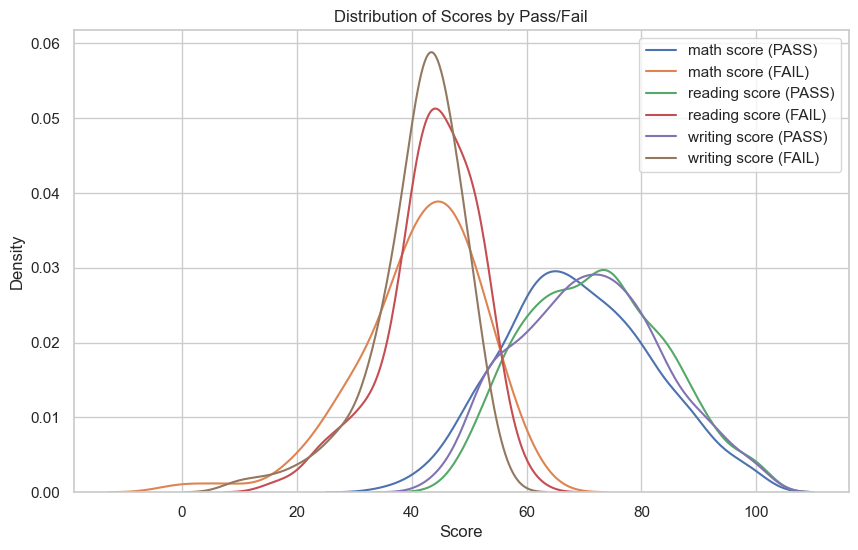

In [15]:

numeric_cols = ["math score", "reading score", "writing score"]

# reload original data for visualization
df_corr = pd.read_csv("StudentsPerformance.csv")

# add target column back
df_corr["pass_fail"] = df["pass_fail"]

plt.figure(figsize=(10,6))

for col in numeric_cols:
    sns.kdeplot(df_corr[df_corr["pass_fail"] == 1][col],
                label=f"{col} (PASS)")
    sns.kdeplot(df_corr[df_corr["pass_fail"] == 0][col],
                label=f"{col} (FAIL)")

plt.title("Distribution of Scores by Pass/Fail")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()



## **Logistic Regression Coefficients**

Coefficients from the trained logistic regression model are extracted. All the features are ranked by their coefficients to identify the strogest predictor.

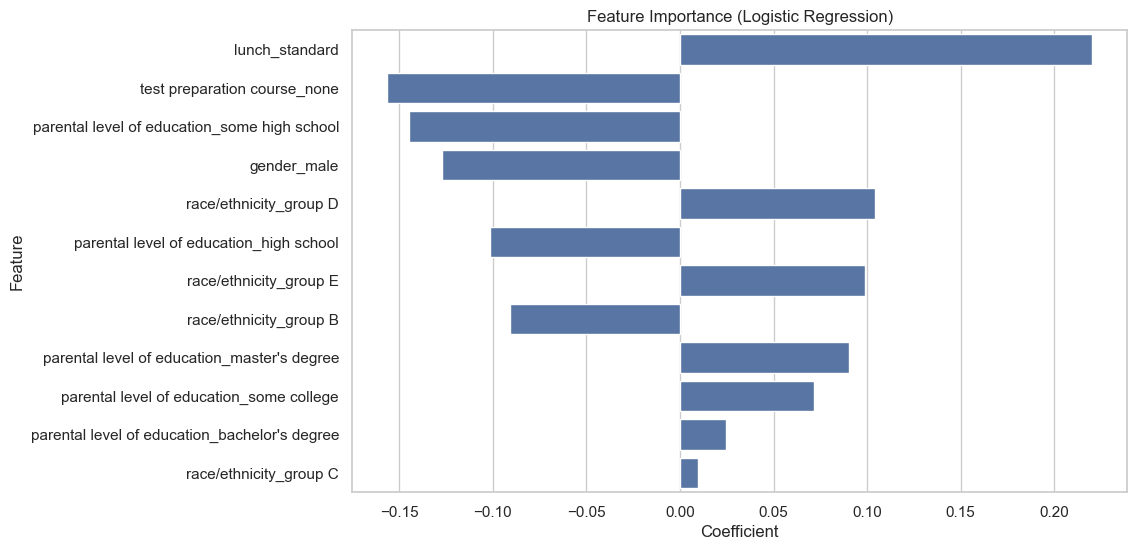

In [16]:
lr_model = lr_grid.best_estimator_.named_steps["lr"]
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Feature Importance (Logistic Regression)")
plt.show()


## **Confusion Matrix Visualization**

The heatmap is generated for the best model prediction. This helps in visualizing true positives, false positives, true negatives, and false negatives.

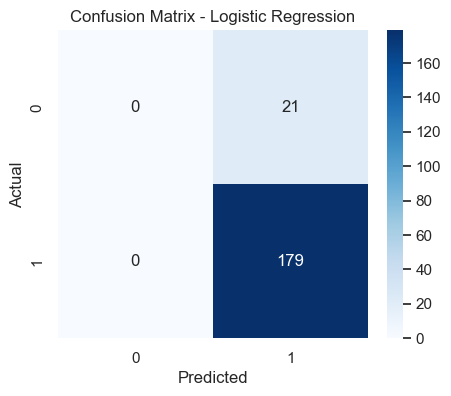

In [17]:
cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


## **ROC Curve Comparison**

ROC curves are plotted for all trained models. The Area Under the Curve (AUC) is displayed to compare discriminative performance.

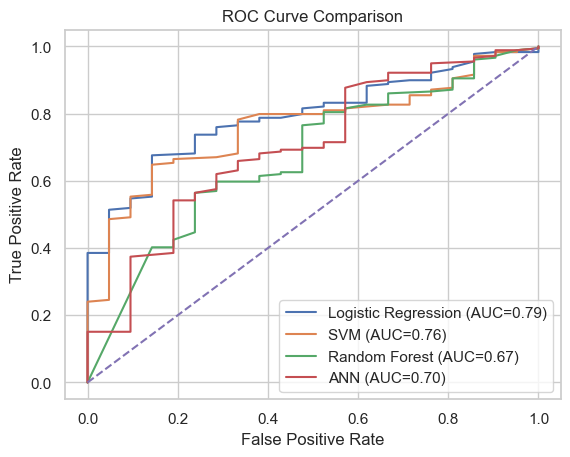

In [18]:
plt.figure()

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["Probs"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{r['Model']} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## **Confusion Matrix**

The selected best model is display confusion matrix by using Scikit-learn's built-in visualization.

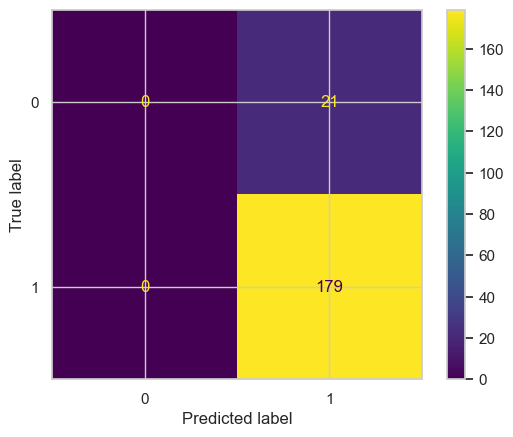

In [19]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)
plt.show()


## **Checking Overfitting**

Accuracy is calculated on both training set and testing set, this helps on determinig if the model is overfitting or not.

In [20]:
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_preds))
print("Test Accuracy:", accuracy_score(y_test, test_preds))


Train Accuracy: 0.8975
Test Accuracy: 0.895


## **Working Prediction**

The user are required to enter student demographic and academic details, then the trained model will predict whether the student is likely to **PASS or FAIL**

In [ ]:
print("Enter student details to predict pass/fail:\n")

gender = input("Gender (male/female): ").strip().lower()
race = input("Race/Ethnicity (group A/B/C/D/E): ").strip()
parent_edu = input("Parental level of education: ").strip()
lunch = input("Lunch type (standard/free/reduced): ").strip()
prep = input("Test preparation course (completed/none): ").strip()

reading = float(input("Reading score (0–100): "))
writing = float(input("Writing score (0–100): "))
math = float(input("Math score (0–100): "))

# -------------------------------
# Create input DataFrame
# -------------------------------

student_input = pd.DataFrame([{
    "gender": gender,
    "race/ethnicity": race,
    "parental level of education": parent_edu,
    "lunch": lunch,
    "test preparation course": prep,
    "reading score": reading,
    "writing score": writing,
    "math score": math
}])

# -------------------------------
# Pick ONE already-trained model safely
# (Random Forest > ANN > SVM > LR)
# -------------------------------

if "rf_grid" in globals():
    model = rf_grid.best_estimator_
    model_name = "Random Forest"
elif "ann_grid" in globals():
    model = ann_grid.best_estimator_
    model_name = "ANN"
elif "best_svm" in globals():
    model = best_svm
    model_name = "SVM"
else:
    model = best_lr
    model_name = "Logistic Regression"

# -------------------------------
# Align input with training features
# -------------------------------

X_input = pd.get_dummies(student_input)

# Match training columns exactly
X_input = X_input.reindex(columns=X_train.columns, fill_value=0)

# -------------------------------
# Predict
# -------------------------------

prediction = model.predict(X_input)[0]

probability = None
if hasattr(model, "predict_proba"):
    probability = model.predict_proba(X_input)[0][1]

# -------------------------------
# Output
# -------------------------------

print("\nPrediction Result")
print("-----------------")
print("Model used:", model_name)
print("Result:", "PASS ✅" if prediction == 1 else "FAIL ❌")

if probability is not None:
    print(f"Probability of passing: {probability:.2%}")


Enter student details to predict pass/fail:



## **Ethical Considerations**

The use of machine learning in educational data is associated with significant ethical concerns that are not limited to specific technical performance. These issues are recognized in this project and responsible use of data and a responsible deployment of models are promoted.

### **1. Consent and Data Ownership**
The collection and use of students and institutions data must be known. Where feasible, the datasets must be acquired in a manner that is well-conceived with specific educational reasons.

### **2. Social Effects of Predictive Systems**
The predictive models can play a role in changing the perception of students or how they are treated by teachers. Wrong predictions would have an adverse impact on motivation or opportunities. There should be caution that these systems should not stigmatize the students or label them too early.

### **3. Equal Educational Opportunities.**
As the past can encode structural inequalities, predictive models can augment inequities. Particular concern should also be given to the question of whether some groups are systematically defined as at-risk and whether the intervention strategies are distributed fairly.

### **4. Model Uncertainty and Reliability.**
There is no flawless model and prediction mistakes are bound to happen. There should be awareness of confidence levels and error rates among decision-makers before acting on the results. The educational environments are dynamic thus the need to undergo re-training and validation periodically.


This project warns of the need to balance technical innovation with ethical consciousness when handling sensitive educational data by focusing on these issues.


## **Conclusion**

This project introduced machine learning methods to determine student academic performance through assessment and demographic data. A variety of classifiers were trained and evaluated, and they included Logistic Regression, Support Vector Machines, random forests, Neural Networks through systematic preprocessing, feature engineering, and model evaluation.

It used various measures of performance to embody the various dimensions of a classification quality, and weighted ranking took place in determining the most appropriate model to use in this task. The use of visualization tools like correlation matrices, feature importance plot, ROC curves and confusion matrices gave more insight into the data and also into how the models behave.

In addition to the technical outcomes, the project focused on the utility of predictive analytics in education in general. The ethical issues, including fairness, transparency, consent and responsible use, became the primary focus of the modeling process and not the afterthoughts. These considerations point to the fact that predictive systems should be implemented with caution, and human control and regular assessment.

Although the chosen model showed encouraging results, the results are limited by the size and the scope of the data. The analysis might be extended in the future to include other educational factors, to provide fairness audits of the different demographic groups, and to test the models using data collected in other institutions or over time.

In general, this research demonstrates that data-intensive approaches can be effective in helping to intervene in academic achievements early and allocate resources in the first place in case of ethical consciousness, readability, and responsible leadership.
